In [23]:
#Importações
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Configurações visuais
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Todas as bibliotecas importadas com sucesso.")

Todas as bibliotecas importadas com sucesso.


In [24]:
#Criação do Dataset
np.random.seed(42)

QTD_REGISTROS = 50

catalogo_livros = {
    "Dom Casmurro": ("Literatura", 35.90),
    "O Pequeno Príncipe": ("Infantil", 29.90),
    "Sapiens": ("Ciências", 54.90),
    "Python para Dados": ("Tecnologia", 89.90),
    "Clean Code": ("Tecnologia", 95.00),
    "Harry Potter Vol.1": ("Fantasia", 49.90),
    "Atomic Habits": ("Autoajuda", 44.90),
    "A Arte da Guerra": ("Filosofia", 32.00),
    "Cosmos": ("Ciências", 62.50),
    "Cem Anos de Solidão": ("Literatura", 39.90)
}

equipe_vendas = ["Ana Lima", "Carlos Mendes", "Bruno Costa", "Fernanda Rocha"]
areas_atuacao = ["Sudeste", "Sul", "Nordeste", "Norte", "Centro-Oeste"]

periodo_vendas = pd.date_range(start="2024-01-01", end="2024-06-30", periods=QTD_REGISTROS)
livros_sorteados = np.random.choice(list(catalogo_livros.keys()), size=QTD_REGISTROS)

historico_vendas = {
    "id_venda": list(range(1, QTD_REGISTROS + 1)),
    "data": periodo_vendas.strftime("%Y-%m-%d"),
    "produto": livros_sorteados,
    "categoria": [catalogo_livros[item][0] for item in livros_sorteados],
    "quantidade": np.random.randint(1, 6, size=QTD_REGISTROS),
    "preco_unit": [catalogo_livros[item][1] for item in livros_sorteados],
    "vendedor": np.random.choice(equipe_vendas, size=QTD_REGISTROS),
    "regiao": np.random.choice(areas_atuacao, size=QTD_REGISTROS)
}

tabela_final = pd.DataFrame(historico_vendas)

tabela_final["total_venda"] = tabela_final["quantidade"] * tabela_final["preco_unit"]

tabela_final.head()

,id_venda,data,produto,categoria,quantidade,preco_unit,vendedor,regiao,total_venda
0,1,2024-01-01,Atomic Habits,Autoajuda,3,44.9,Ana Lima,Centro-Oeste,134.7
1,2,2024-01-04,Python para Dados,Tecnologia,1,89.9,Fernanda Rocha,Norte,89.9
2,3,2024-01-08,A Arte da Guerra,Filosofia,4,32.0,Bruno Costa,Centro-Oeste,128.0
3,4,2024-01-12,Clean Code,Tecnologia,2,95.0,Bruno Costa,Nordeste,190.0
4,5,2024-01-15,Atomic Habits,Autoajuda,4,44.9,Carlos Mendes,Nordeste,179.6


In [25]:
#Exploração inicial
dados_vendas = pd.read_csv("vendas_livraria.csv")

print("=" * 40)
print(" RESUMO DA BASE DE DADOS ".center(40))
print("=" * 40)
print(f"Total de Registros: {dados_vendas.shape[0]}\nTotal de Variáveis: {dados_vendas.shape[1]}")

print("\n--- FORMATO DAS COLUNAS ---")
print(dados_vendas.dtypes)

print("\n--- DADOS FALTANTES ---")
print(dados_vendas.isna().sum())

print("\n--- RESUMO ESTATÍSTICO ---")
print(dados_vendas[["quantidade", "preco_unit", "total_venda"]].describe().round(2))

        RESUMO DA BASE DE DADOS         
Total de Registros: 50
Total de Variáveis: 9

--- FORMATO DAS COLUNAS ---
id_venda         int64
data               str
produto            str
categoria          str
quantidade       int64
preco_unit     float64
vendedor           str
regiao             str
total_venda    float64
dtype: object

--- DADOS FALTANTES ---
id_venda       0
data           0
produto        0
categoria      0
quantidade     0
preco_unit     0
vendedor       0
regiao         0
total_venda    0
dtype: int64

--- RESUMO ESTATÍSTICO ---
       quantidade  preco_unit  total_venda
count       50.00       50.00        50.00
mean         2.84       55.57       150.77
std          1.45       23.27        98.01
min          1.00       29.90        29.90
25%          2.00       36.90        79.80
50%          3.00       47.40       128.00
75%          4.00       62.50       190.00
max          5.00       95.00       475.00


In [26]:
#Análise de vendas
faturamento_geral = dados_vendas["total_venda"].sum()
print(f"Faturamento Bruto: R$ {faturamento_geral:,.2f}")

receita_categoria = dados_vendas.groupby("categoria")["total_venda"].sum().sort_values(ascending=False)
print("\n--- Receita por Categoria ---")
print(receita_categoria.map("R$ {:,.2f}".format))

desempenho_vendedores = dados_vendas.groupby("vendedor")["total_venda"].sum().sort_values(ascending=False)
print("\n--- Vendas por Funcionário ---")
print(desempenho_vendedores.map("R$ {:,.2f}".format))

mais_vendidos = dados_vendas.groupby("produto")["quantidade"].sum().nlargest(3)
print("\n--- 3 Produtos Mais Populares ---")
print(mais_vendidos)

ticket_regiao = dados_vendas.groupby("regiao")["total_venda"].mean().sort_values(ascending=False).round(2)
print("\n--- Ticket Médio Geográfico ---")
print(ticket_regiao.map("R$ {:,.2f}".format))

Faturamento Bruto: R$ 7,538.40

--- Receita por Categoria ---
categoria
Tecnologia    R$ 2,788.80
Autoajuda     R$ 1,122.50
Ciências      R$ 1,071.80
Literatura      R$ 813.90
Filosofia       R$ 704.00
Fantasia        R$ 648.70
Infantil        R$ 388.70
Name: total_venda, dtype: str

--- Vendas por Funcionário ---
vendedor
Bruno Costa       R$ 3,392.90
Ana Lima          R$ 1,700.80
Fernanda Rocha    R$ 1,361.10
Carlos Mendes     R$ 1,083.60
Name: total_venda, dtype: str

--- 3 Produtos Mais Populares ---
produto
Atomic Habits       25
A Arte da Guerra    22
Clean Code          18
Name: quantidade, dtype: int64

--- Ticket Médio Geográfico ---
regiao
Nordeste        R$ 178.94
Norte           R$ 164.88
Sudeste         R$ 135.95
Centro-Oeste    R$ 135.26
Sul             R$ 133.08
Name: total_venda, dtype: str


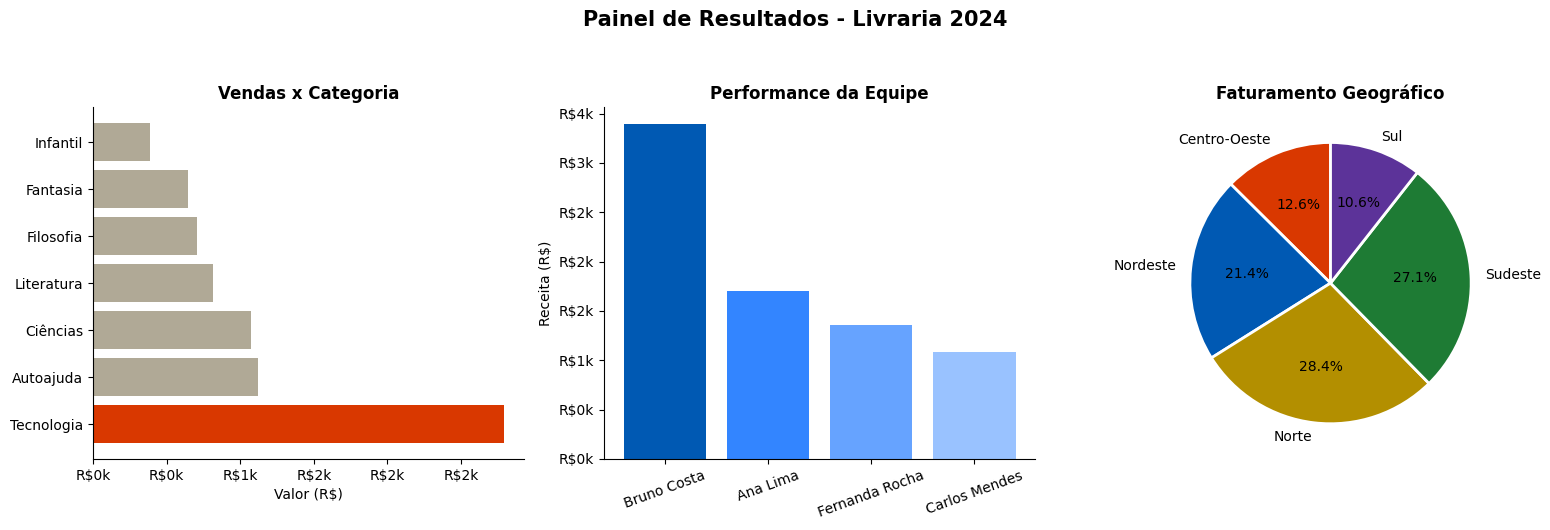

Arquivos de imagem gerados com sucesso.


In [27]:
#Visualizações
figura, graficos = plt.subplots(1, 3, figsize=(16, 5))
figura.suptitle("Painel de Resultados - Livraria 2024", fontsize=15, weight="bold", y=1.05)

#Gráfico I - faturamento por categoria
g_cat = graficos[0]
paleta_cat = ["#d93800" if idx == 0 else "#b0a996" for idx in range(len(receita_categoria))]
g_cat.barh(receita_categoria.index, receita_categoria.values, color=paleta_cat)
g_cat.set_title("Vendas x Categoria", weight="bold")
g_cat.set_xlabel("Valor (R$)")
g_cat.xaxis.set_major_formatter(mticker.FuncFormatter(lambda valor, _: f"R${valor/1000:.0f}k"))

#Gráfico II - ranking vendedores
g_vend = graficos[1]
cores_vendedores = ["#0059b3", "#3385ff", "#66a3ff", "#99c2ff"]
g_vend.bar(desempenho_vendedores.index, desempenho_vendedores.values, color=cores_vendedores)
g_vend.set_title("Performance da Equipe", weight="bold")
g_vend.set_ylabel("Receita (R$)")
g_vend.yaxis.set_major_formatter(mticker.FuncFormatter(lambda valor, _: f"R${valor/1000:.0f}k"))
g_vend.tick_params(axis="x", rotation=20)

#Gráfico III - distribuição das regiões
g_reg = graficos[2]
vendas_regiao = dados_vendas.groupby("regiao")["total_venda"].sum()
g_reg.pie(
    vendas_regiao,
    labels=vendas_regiao.index,
    autopct="%1.1f%%",
    colors=["#d93800", "#0059b3", "#b38f00", "#1e7b34", "#5c3399"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
g_reg.set_title("Faturamento Geográfico", weight="bold")

plt.tight_layout()
plt.savefig("painel_gerencial.png", dpi=150, bbox_inches="tight")
plt.show()
print("Arquivos de imagem gerados com sucesso.")

In [28]:
#Desafio I
dados_vendas["mes_venda"] = pd.to_datetime(dados_vendas["data"]).dt.month
receita_por_mes = dados_vendas.groupby("mes_venda")["total_venda"].sum()
print("Resultado Mensal:")
print(receita_por_mes.map("R$ {:,.2f}".format))

Resultado Mensal:
mes_venda
1    R$ 1,251.40
2    R$ 1,281.10
3    R$ 1,505.60
4    R$ 1,284.40
5    R$ 1,263.50
6      R$ 952.40
Name: total_venda, dtype: str


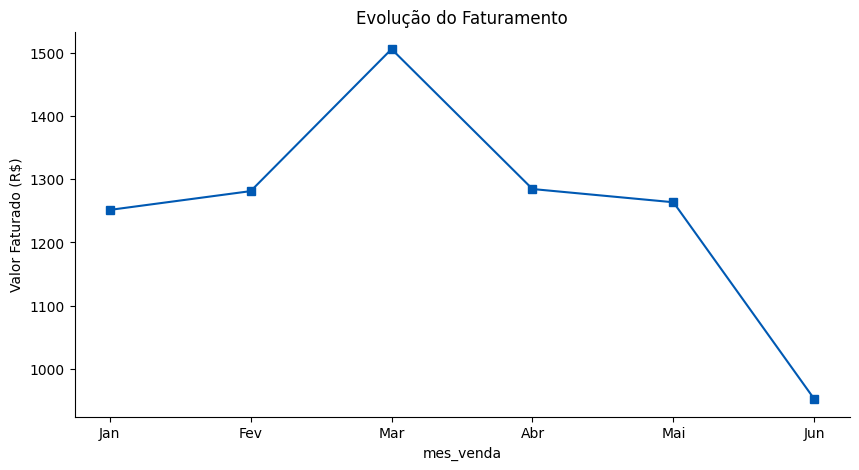

In [29]:
#Desafio II
receita_por_mes.plot(kind='line', marker='s', figsize=(10, 5), color='#0059b3', title="Evolução do Faturamento")
plt.xticks(ticks=receita_por_mes.index, labels=['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun'])
plt.ylabel("Valor Faturado (R$)")
plt.savefig("grafico_tendencia.png", bbox_inches="tight")
plt.show()

In [30]:
#Desafio III
print("Ticket Médio - Equipe:")
print(dados_vendas.groupby("vendedor")["total_venda"].mean().sort_values(ascending=False).map("R$ {:,.2f}".format))

Ticket Médio - Equipe:
vendedor
Bruno Costa       R$ 161.57
Fernanda Rocha    R$ 151.23
Ana Lima          R$ 141.73
Carlos Mendes     R$ 135.45
Name: total_venda, dtype: str


In [31]:
#Desafio IV
print("Principais categorias em pedidos acima de R$ 200:")
print(dados_vendas.query("total_venda > 200")["categoria"].value_counts())

Principais categorias em pedidos acima de R$ 200:
categoria
Tecnologia    5
Fantasia      1
Ciências      1
Autoajuda     1
Name: count, dtype: int64


In [32]:
#Desafio V
dados_faltantes = pd.DataFrame({
    "id_venda": [51, 52, 53, 54, 55],
    "data": [np.nan, "2024-07-02", np.nan, "2024-07-04", "2024-07-05"],
    "produto": [np.nan, "Sapiens", "Cosmos", np.nan, "Clean Code"],
    "categoria": [np.nan, "Ciências", "Ciências", np.nan, "Tecnologia"],
    "quantidade": [np.nan, 2, np.nan, 1, 3],
    "preco_unit": [np.nan, 54.9, 62.5, np.nan, 95.0],
    "vendedor": ["Ana Lima", np.nan, "Bruno Costa", np.nan, "Fernanda Rocha"],
    "regiao": ["Sul", "Sudeste", np.nan, "Norte", np.nan],
    "total_venda": [np.nan, 109.8, np.nan, np.nan, 285.0]
})

tabela_suja = pd.concat([dados_vendas, dados_faltantes], ignore_index=True)
print("Verificação de nulos (antes):")
print(tabela_suja.isna().sum())

mediana_qtd = tabela_suja["quantidade"].median()
tabela_limpa = tabela_suja.dropna(subset=['total_venda']).fillna({
    "vendedor": "Não Identificado",
    "quantidade": mediana_qtd
})

print("\nVerificação de nulos (depois):")
print(tabela_limpa.isna().sum())

Verificação de nulos (antes):
id_venda       0
data           2
produto        2
categoria      2
quantidade     2
preco_unit     2
vendedor       2
regiao         2
total_venda    3
mes_venda      5
dtype: int64

Verificação de nulos (depois):
id_venda       0
data           0
produto        0
categoria      0
quantidade     0
preco_unit     0
vendedor       0
regiao         1
total_venda    0
mes_venda      2
dtype: int64
